In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [20]:
import json
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
from pathlib import Path
import sys
import pandas as pd

import cogwheel.gw_plotting
from cogwheel import data

import gwosc
import gwpy.table
from pesummary.io import read

sys.path.insert(0, '../code')
from parameter_estimation import get_chirp_mass, get_table_data

In [6]:
eventname = 'GW230518_125908'
catalog = 'GWTC-4.0'
output_dir = Path(os.path.join('/home/javier.roulet/cogwheel-catalog/processed_data', catalog, eventname))
event_data = data.EventData.from_npz(filename=output_dir/f'{eventname}.npz')

In [14]:
# what's the table data for this event?
event_table = get_table_data(eventname, catalog)
event_table

name,chirp_mass,p_astro_upper,version,far_lower,chi_eff_lower,jsonurl,catalog.shortName,chirp_mass_lower,far,chirp_mass_source_upper,redshift_lower,p_astro_lower,final_mass_source_lower,GPS,p_astro,far_upper,chi_eff,final_mass_source,final_mass_source_upper,mass_1_source,network_matched_filter_snr,luminosity_distance,commonName,total_mass_source,chirp_mass_upper,reference,network_matched_filter_snr_upper,mass_2_source,redshift_upper,network_matched_filter_snr_lower,chirp_mass_source,luminosity_distance_lower,chirp_mass_source_lower,mass_2_source_upper,mass_1_source_lower,total_mass_source_upper,mass_1_source_upper,mass_2_source_lower,total_mass_source_lower,luminosity_distance_upper,redshift,chi_eff_upper
,,,,1 / yr,,,,,1 / yr,solMass,,,,,,1 / yr,,,,solMass,,Mpc,,solMass,,,,solMass,,,solMass,Mpc,solMass,solMass,solMass,solMass,solMass,solMass,solMass,Mpc,,
str18,object,object,int64,object,object,str59,str8,object,float64,object,object,object,object,float64,float64,object,object,object,object,object,float64,object,str15,object,object,str19,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object
GW230518_125908-v1,None,None,1,None,-0.11,https://gwosc.org/eventapi/json/GWTC-4.0/GW230518_125908/v1,GWTC-4.0,None,1e-05,0.06,-0.02,None,None,1368449966.2,0.99,None,-0.01,None,None,8.17,14.1,236.0,GW230518_125908,9.61,None,/GWTC-4.0/,None,1.45,0.02,None,2.8,-96.0,-0.06,0.13,-0.92,0.76,0.84,-0.1,-0.79,108.0,0.05,0.09


In [21]:
# what's the chirp mass?
get_chirp_mass(event_table)

2.94

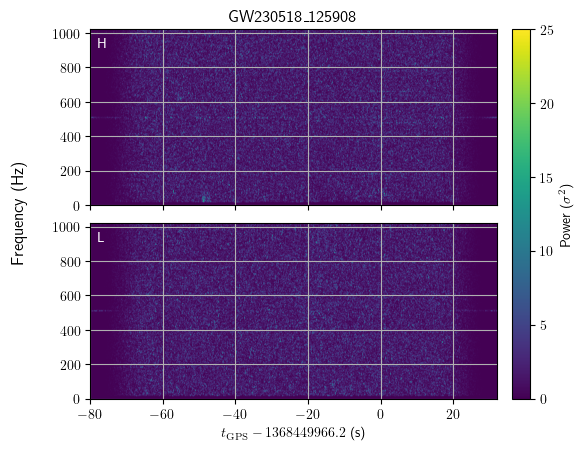

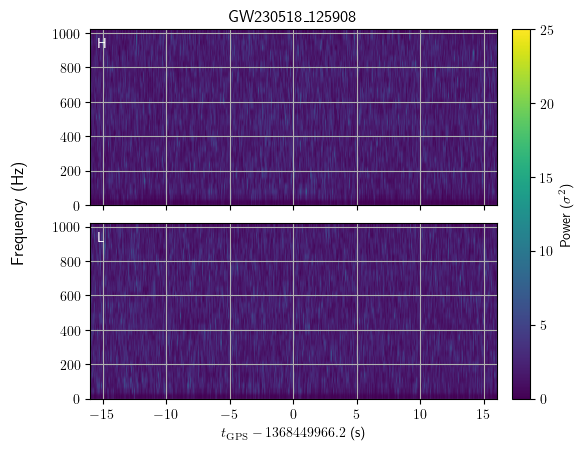

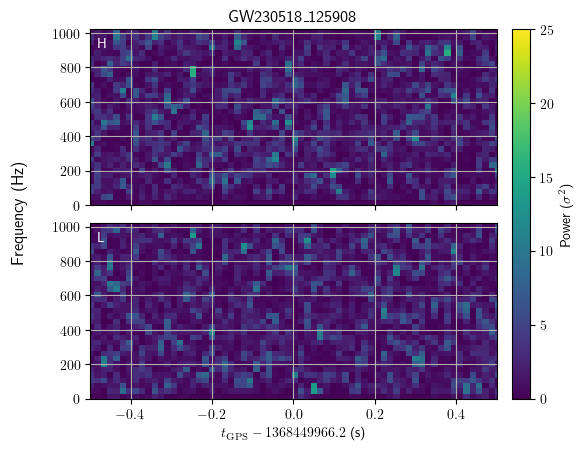

In [8]:
# check out the spectrogram
event_data.specgram(nfft=512)
kwargs = dict(
    fmax = 256,
    wht_filter_duration = 32,
    t_before = 32,
    t_after = 16
)
event_data.specgram(np.multiply(kwargs.get('wht_filter_duration', 32), (-.5, .5)))
event_data.specgram((-.5, .5))
plt.show()

In [9]:
def load_posterior_samples(eventname, event_path):
    # find the "earliest" run with posterior samples
    i = 0
    while i < 10:
        try:
            samples = pd.read_feather(os.path.join(event_path, f'run_{i}', 'samples.feather'))
            print(f"loaded posterior samples for {eventname} run {i}")
            break
        except FileNotFoundError:
            i += 1

    # add derived quantities
    # add_derived_quantities(samples)

    # load the posterior samples from the LIGO PE data release
    pe_data_fn = f"../data/pe_data_release/IGWN-GWTC4p0-1a206db3d_721-{eventname}-combined_PEDataRelease.hdf5"
    data = read(pe_data_fn)
    # get the posterior samples using the IMRPhenomXPHM approximant
    samples_lvk = data.samples_dict["C00:IMRPhenomXPHM-SpinTaylor"]

    return samples, samples_lvk

In [10]:
# where we've saved the posteriors and samples
resdir = '../data/pe_runs_lensing/IntrinsicLVCPrior'
event_path = os.path.join(resdir, eventname)
samples, samples_lvk = load_posterior_samples(eventname, event_path)

2026-01-21  14:54:13 PESummary WARNING : Unable to install 'pycbc'. You will not be able to use some of the inbuilt functions.
2026-01-21  14:54:13 PESummary WARNING : Unable to install 'pycbc'. You will not be able to use some of the inbuilt functions.


loaded posterior samples for GW230518_125908 run 0


2026-01-21  14:54:17 PESummary WARNING : Tidal deformability parameters found in the posterior table but they are all exactly 0. Assuming this is a BBH system.
2026-01-21  14:54:17 PESummary WARNING : Posterior samples for lambda_1 and lambda_2 found in the posterior table but lambda_1 is always exactly 0. Assuming this is an NSBH system.
2026-01-21  14:54:17 PESummary WARNING : Tidal deformability parameters found in the posterior table but they are all exactly 0. Assuming this is a BBH system.
2026-01-21  14:54:17 PESummary WARNING : Posterior samples for lambda_1 and lambda_2 found in the posterior table but lambda_1 is always exactly 0. Assuming this is an NSBH system.
2026-01-21  14:54:17 PESummary WARNING : You have supplied the waveform model: 'IMRPhenomPv2_NRTidalv2'. Currently only the IMRPhenomNSBH waveform model can be used. Unable to calculate the NSBH conversion
2026-01-21  14:54:17 PESummary WARNING : You have supplied the waveform model: 'IMRPhenomPv2_NRTidalv2'. Current

In [11]:
plot_params = [
    'mchirp',
    'lnq',
    'iota',
    'phi_ref',
    'psi',
    'd_luminosity',
    'p_lensed'
]

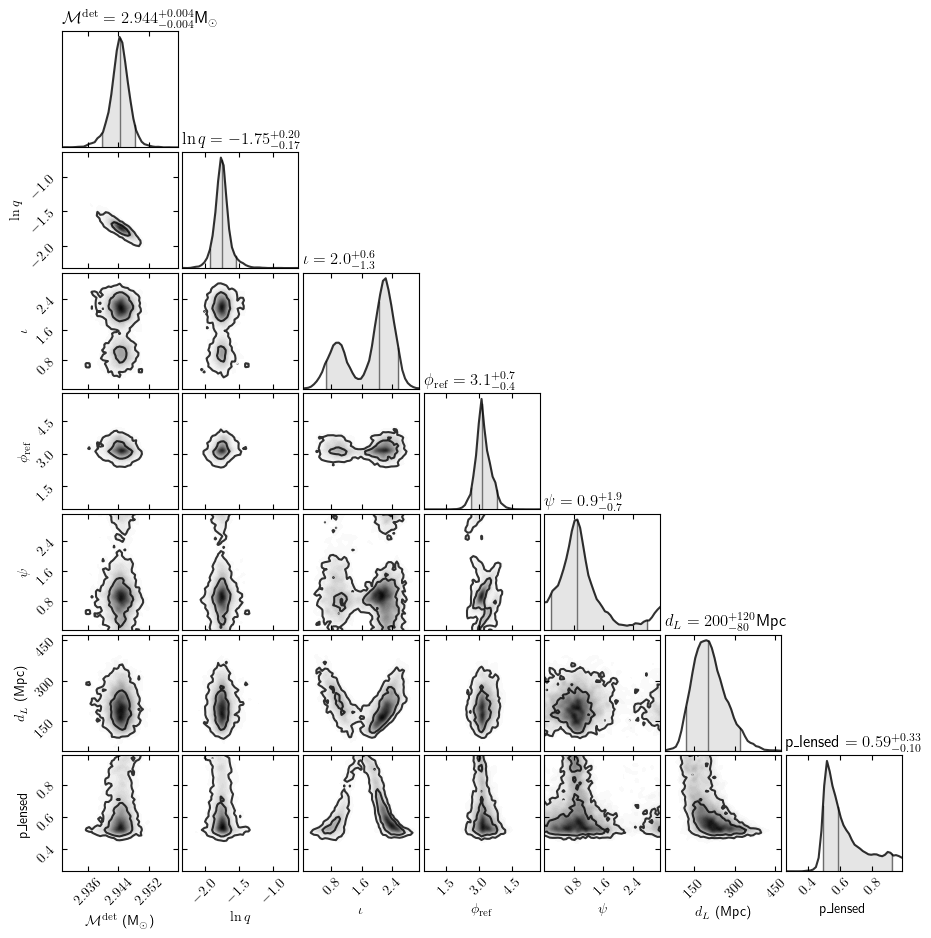

In [19]:
corner_plot = cogwheel.gw_plotting.CornerPlot(
        samples, params=plot_params, tail_probability=1e-4, color_2d='k',
        kwargs_1d=dict(color='k', alpha=0.8), contour_kwargs=dict(alpha=0.8)
)
corner_plot.plot()
# corner_plot.scatter_points(table_plot_points, colors=['#998AFF'], s=150,
#                                zorder=2, marker='+', adjust_lims=True)

<Axes: xlabel='phi_ref', ylabel='p_lensed'>

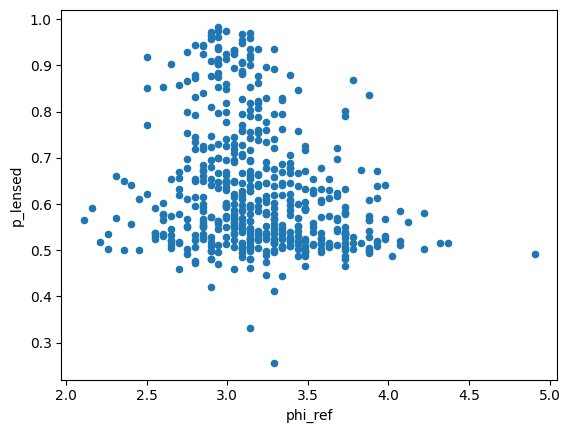

In [11]:
mask = np.random.uniform(size=len(samples)) < (samples['weights'] / samples['weights'].max())
samples[mask].plot('phi_ref', 'p_lensed', 'scatter')

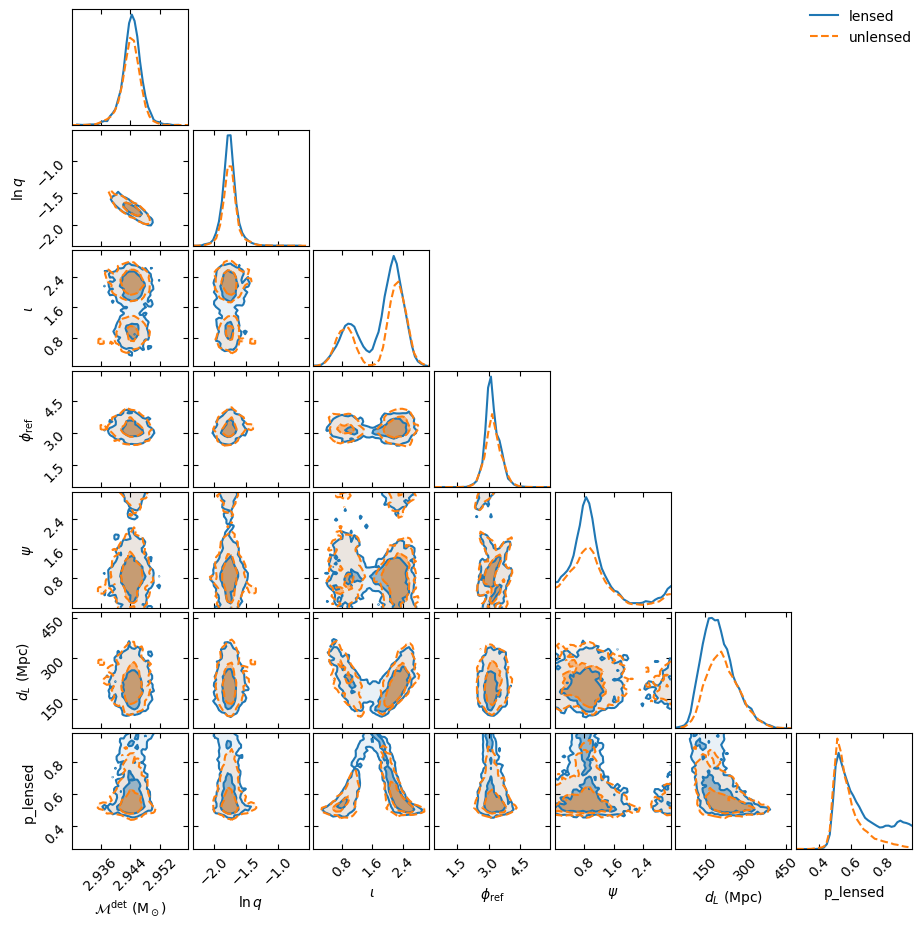

In [12]:
# posterior assuming everything is lensed
lensed = np.random.uniform(size=len(samples)) < samples['p_lensed']

corner_plot = cogwheel.gw_plotting.MultiCornerPlot(
        {'lensed' : samples[lensed], 'unlensed' : samples[~lensed]}, params=plot_params, tail_probability=1e-4, density=False
)
corner_plot.plot()